In [1]:
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import replace

import run_config
import utils_lya_halo

from run_config import cfg, smoke
from utils_lya_halo import (run_extract, run_stack, measure, validation,
                            plotting, analysis, multicat, selection, core, stack)
from utils_lya_halo.stack import build_stacks
from utils_lya_halo.io import read_galaxy_fits, apply_finite_cut
from utils_lya_halo import starpsf

LYA_REST = PipelineConfig.LYA_REST

import warnings
from astropy.utils.exceptions import AstropyUserWarning

warnings.filterwarnings(
    "ignore",
    message="Input data contains invalid values.*",
    category=AstropyUserWarning,
)

# Reading in output and stacking

In [7]:
# ---------------------------------------------------------------- INPUTS
random_seed     = 10
bin_mode        = 'kpc'
bins            = [0, 10, 20, 30, 50, 80, 140, 300, 600, 1000, 2000]
field           = 'BOTH'

half_width      = 3.0            # +/- Angstrom around LYA_REST used as the "line" (Stage 3)
vr_approx       = 80             # rough |v| scale (km/s) -- not consumed in this cell;
                                # handy later e.g. plot_centroid_profile(..., ylims=(-3*vr_approx, 3*vr_approx))
stack_method    = 'biweight'
mask_method     = "segmap"

id_col          = "ID"

bg_inner_arcsec = 80
bg_outer_arcsec = 90

rest_wave_min   = 1100
rest_wave_max   = 1700
spexlim         = (rest_wave_min, rest_wave_max)

n_bootstrap     = 3000
np.random.seed(random_seed)    # reproducibility for anything you resample by hand below

# ---------------------------------------------------------------- CONFIG (drives everything below)
cfg2 = replace(cfg,
    field=field,
    bin_mode=bin_mode,
    bins=bins,
    mask_method=mask_method,
    bg_inner_arcsec=bg_inner_arcsec,
    bg_outer_arcsec=bg_outer_arcsec,
    rest_wave_min=rest_wave_min,
    rest_wave_max=rest_wave_max,
    n_bootstrap=n_bootstrap,
    #flux_unit='flux_arcsec2',
    #rest_density=False,
    line_window=[LYA_REST - half_width, LYA_REST + half_width])

# ---------------------------------------------------------------- FILE PATHS
# one dict keyed by bin_mode -- add a new bin_mode by adding a key, no new elif
PRODUCT_PATHS = {
    'virial': {
        'AEGIS':  './outputs/galaxy_catc1488c_b8_8c91de_AEGIS_MOSDEF_virial_biweight_image_bg57-63.fits',
        'COSMOS': './outputs/galaxy_catc1488c_b8_8c91de_COSMOS_MOSDEF_virial_biweight_image_bg57-63.fits',
    },
    'kpc': {
        'AEGIS':  './outputs/galaxy_cat65a007_b10_ec8c16_AEGIS_MOSDEF_kpc_biweight_segmap_bg80-90.fits',
        'COSMOS': './outputs/galaxy_cat65a007_b10_ec8c16_COSMOS_MOSDEF_kpc_biweight_segmap_bg80-90.fits',
    },
}
try:
    paths = PRODUCT_PATHS[bin_mode.lower()]
except KeyError:
    raise ValueError(f"No file paths registered for bin_mode={bin_mode!r} "
                     f"(have: {list(PRODUCT_PATHS)}); add it to PRODUCT_PATHS.")

# ---------------------------------------------------------------- LOAD + CUT (per field)
products = {
    label: apply_finite_cut(read_galaxy_fits(path),
                            cfg2.cut_radial_bin, cfg2.min_good_wave)
    for label, path in paths.items()
}
product1, product2 = products['AEGIS'], products['COSMOS']   # kept for compatibility with older cells

# ---------------------------------------------------------------- (BOTH) COMBINE + STACK
prod_combined = multicat.combine_products(products, label_col="SUBSET")

print(f"AEGIS: {np.round(np.median(product1.nfib, axis=0), 3).astype(int)}")
print(f"COSMOS: {np.round(np.median(product2.nfib, axis=0), 3).astype(int)}")
print(f"COMBINED: {np.round(np.median(prod_combined.nfib, axis=0), 3).astype(int)}")

# ---------------------------------------------------------------- (SINGLE) COMBINE + STACK
stacks_by_field = multicat.stack_each(cfg2, products, keep_cube=True)   # {'AEGIS':stacks,'COSMOS':stacks}
stacks_all = stack.build_stacks(cfg2, prod_combined, keep_cube=True)

print(f"BOTH:   {prod_combined.ngal} galaxies")
print(f"AEGIS:  {products['AEGIS'].ngal} galaxies")
print(f"COSMOS: {products['COSMOS'].ngal} galaxies")

# ---------------------------------------------------------------- SEPARATE AGN
sel_agn = prod_combined.catalog["CLEAN"]

groups = selection.split_by_mask(prod_combined, sel_agn, labels=["AGN", "GAL"], verbose=False)
prod_galaxy = groups['GAL']
prod_agn = groups['AGN']

stacks = build_stacks(cfg2, prod_galaxy, keep_cube=True)
stacks_agn = build_stacks(cfg2, prod_agn, keep_cube=True)

print(f"GAL: {prod_galaxy.ngal} sources")
print(f"AGN: {prod_agn.ngal} sources")

# Measuring

In [9]:
#BOOTSTRAP!
boot = measure.measure_all_bins(cfg2, stacks,
    seed=random_seed,
    verbose=True)

▶ bootstrap [median50]  |  nboot=3000  stack=biweight  centroid=median50  window=(1212.67,1218.67)  cont=median  side_ratio=True  stack_err=True  seed=10


bootstrap [median50]:   0%|          | 0/3000 [00:00<?, ?it/s]

In [ ]:
boot = boot_b

# Confidence in Outer-Bin Centroid Signal

In [10]:
res = validation.combined_bin_significance(boot, r_min=100)


Combined significance over 5 bin(s), centers = [110.0, 220.0, 450.0, 800.0, 1500.0] kpc (3000/3000 bootstrap draws finite in all selected bins)
  bin center     v_fid  sqrt(Sigma_ii)
       110.0     -53.9            44.3
       220.0     -57.0            43.0
       450.0     -36.8            40.9
       800.0     -16.6            56.1
      1500.0     -47.6            53.4

correlation matrix between selected bins (induced by shared galaxies across radii in each bootstrap draw):
[[1.   0.15 0.02 0.06 0.06]
 [0.15 1.   0.12 0.03 0.14]
 [0.02 0.12 1.   0.18 0.27]
 [0.06 0.03 0.18 1.   0.32]
 [0.06 0.14 0.27 0.32 1.  ]]

method                          offset     error       z   p (2-sided)
naive (bins independent)         -44.1      20.8   -2.12      3.37e-02
covariance-aware (correct)       -44.9      25.2   -1.78      7.46e-02

Mahalanobis whole-vector test: D^2=3.63, dof=5, p=6.04e-01 (is the FULL pattern across these bins consistent with all-zero, regardless of sign)
one-sided p (

In [13]:
# --- weight_mode='invvar' (recommended): weight bins by how PRECISE they are ---
pooled_invvar = validation.pool_bins_and_bootstrap(
    stacks,                    # build_stacks(..., keep_cube=True) dict
    bins=None,                 # explicit bin indices, e.g. [7,8,9,10,11]; None -> use r_min/r_max
    r_min=100,                 # select every bin with center >= 100 kpc
    r_max=None,                # no upper cutoff (None -> +inf)
    weight_mode="invvar",      # 'invvar' or 'nfib'
    real_boot=boot,            # REQUIRED for invvar (unless bin_weights= is given directly)
    bin_weights=None,          # explicit override array instead of deriving from real_boot
    nboot=cfg2.n_bootstrap,                # bootstrap draws for the fresh pooled measurement
    seed=random_seed,          # RNG seed, for reproducibility
    compute_side_ratio=False,  # skip blue/red side-ratio (not needed for this check)
    verbose=True,              # print the z/p summary
    # anything else here is forwarded straight to bootstrap_measurements, e.g.:
    # centroid_method="flux_weighted", stack_method="biweight", cont_method="median",
)

# # --- weight_mode='nfib': the old fiber-count merge, for comparison ---
# pooled_nfib = val.pool_bins_and_bootstrap(
#     stacks, r_min=100, r_max=None,
#     weight_mode="nfib",        # real_boot not needed in this mode
#     nboot=1000, seed=random_seed, compute_side_ratio=False, verbose=True,
# )

print(pooled_invvar["centroid_v_fid"], pooled_invvar["r_edges"])

▶ pooled bin [invvar] 110-1500 kpc  |  nboot=3000  stack=biweight  centroid=flux_median  window=(1211.67,1219.67)  cont=median  side_ratio=False  seed=10


pooled bin [invvar] 110-1500 kpc:   0%|          | 0/3000 [00:00<?, ?it/s]


Pooled bin (invvar) over centers [110.0, 220.0, 450.0, 800.0, 1500.0] kpc -> merged range [80, 2000] kpc
v_fid = -47.5 km/s, bootstrap 16/84 half-width = 31.5 km/s, z = -1.51, p(2-sided) = 1.32e-01, p(one-sided, true<0) = 6.59e-02
[-47.54101811] [  80. 2000.]


# Total Systematic SN Comparison

In [5]:
#Measure the random z and random wavelength fluxes to get real noise floor
nulls = validation.collect_null_ensembles(cfg, stacks, mega,
    methods=("zswap", "bootstrap", "jackknife"),
    n_zswap=250,
    nboot=n_bootstrap,
    jk_mode="delete-one",      #"block" or "delete-one"
    jk_n_blocks=50,
    jk_n_reps=5,
    method=stack_method,
    seed=random_seed,
    extra_nulls=None,
    keep_zswap_spectra=True,
    verbose=True)

z-scramble (spectra):   0%|          | 0/250 [00:00<?, ?it/s]


z-scramble spectra (250 realizations, method=biweight):
  0-10: real F=+3.81e+39  null σ=2.89e+38  S/N=+12.9
  10-20: real F=+3.18e+39  null σ=1.48e+38  S/N=+21.1
  20-50: real F=+8.7e+38  null σ=5.47e+37  S/N=+16.0
  50-100: real F=+1.52e+38  null σ=3.19e+37  S/N=+4.7
  100-200: real F=+7.68e+37  null σ=1.72e+37  S/N=+4.4
  200-500: real F=+1.87e+37  null σ=8.51e+36  S/N=+2.0
  500-1000: real F=+1.99e+37  null σ=5.87e+36  S/N=+3.2
  1000-2000: real F=+1.55e+37  null σ=4.23e+36  S/N=+3.3


  0%|          | 0/1000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/506 [00:00<?, ?it/s]


null/error ensemble (real Lyα flux):
           bin   z-scramble      σ_boot      σ_jack
          0-10        +12.9    4.19e+38    5.19e+38
         10-20        +21.1    2.22e+38    2.68e+38
         20-50        +16.0    7.51e+37     9.8e+37
        50-100         +4.7    3.64e+37    4.62e+37
       100-200         +4.4    1.81e+37    2.14e+37
       200-500         +2.0     8.2e+36    9.79e+36
      500-1000         +3.2    6.12e+36    7.39e+36
     1000-2000         +3.3    4.29e+36    5.09e+36
  (null S/N = real vs floor; σ_boot/σ_jack are error bars on the real point and should agree)


In [6]:
print("Done")

Done


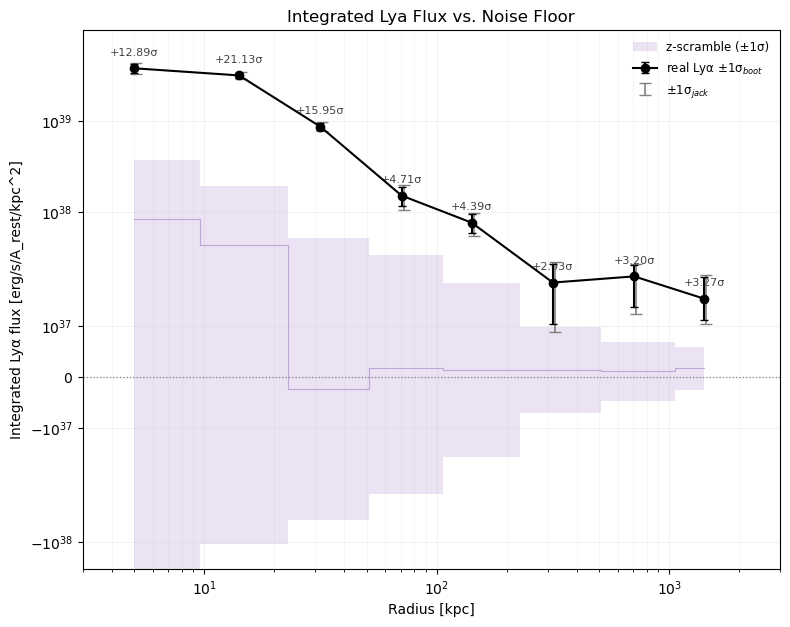

binding null per bin (smallest S/N):
  0-10: z-scramble at +12.9σ
  10-20: z-scramble at +21.1σ
  20-50: z-scramble at +16.0σ
  50-100: z-scramble at +4.7σ
  100-200: z-scramble at +4.4σ
  200-500: z-scramble at +2.0σ
  500-1000: z-scramble at +3.2σ
  1000-2000: z-scramble at +3.3σ


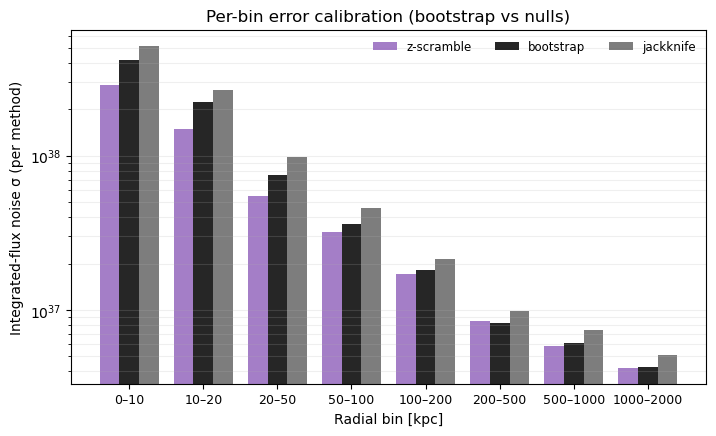

(<Figure size 820x460 with 1 Axes>,
 <Axes: title={'center': 'Per-bin error calibration (bootstrap vs nulls)'}, xlabel='Radial bin [kpc]', ylabel='Integrated-flux noise σ (per method)'>)

In [7]:
validation.plot_null_synthesis(nulls,
    vr_ticks=vr_ticks,
    nsigma=1,
    symlog=True,
    linthresh=2e37,
    ylims=(-2e38, 1e40),
    xlims=xlims,
    figsize=(9, 7),
    title="Integrated Lya Flux vs. Noise Floor", 
    annotate=True,
    save_fig=False,
    savename="Lya_SN_Null_Synthesis.png")

#z-swap σ vs bootstrap σ vs jackknife σ
validation.plot_error_calibration(nulls)

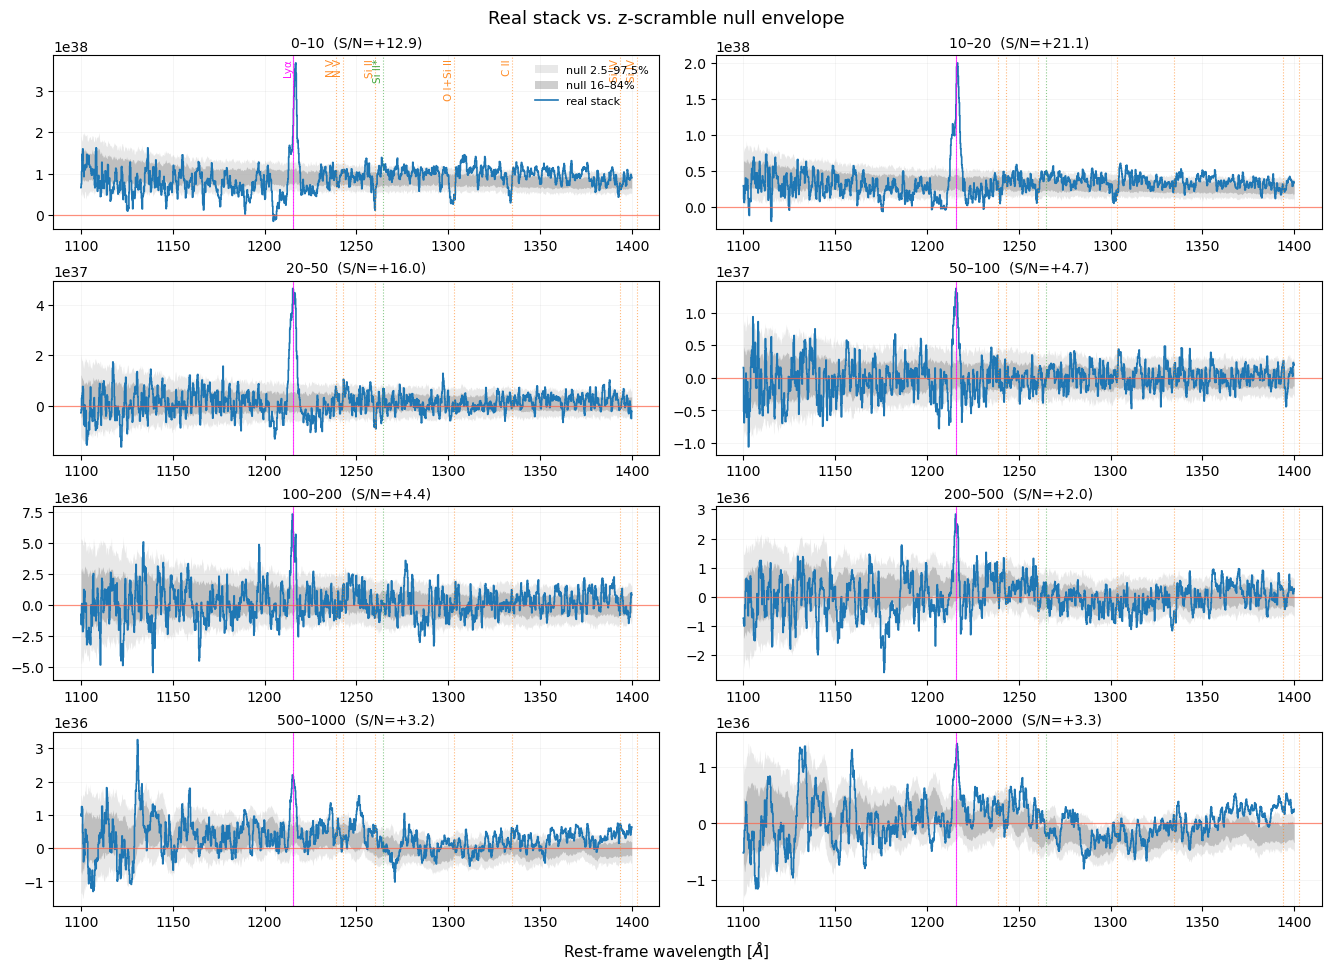

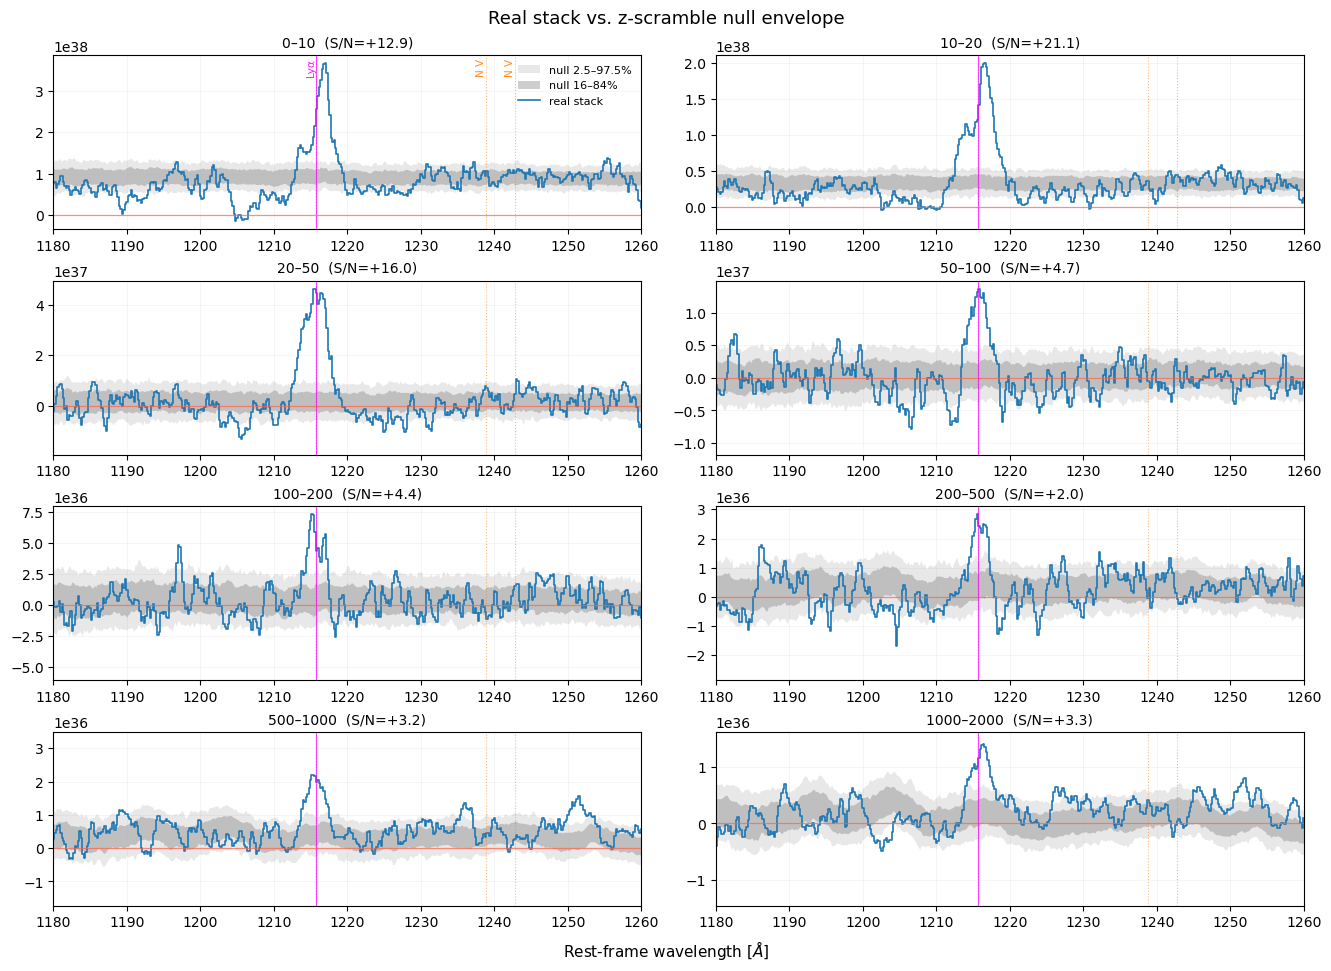

(<Figure size 1320x960 with 8 Axes>,
 array([[<Axes: title={'center': '0–10  (S/N=+12.9)'}>,
         <Axes: title={'center': '10–20  (S/N=+21.1)'}>],
        [<Axes: title={'center': '20–50  (S/N=+16.0)'}>,
         <Axes: title={'center': '50–100  (S/N=+4.7)'}>],
        [<Axes: title={'center': '100–200  (S/N=+4.4)'}>,
         <Axes: title={'center': '200–500  (S/N=+2.0)'}>],
        [<Axes: title={'center': '500–1000  (S/N=+3.2)'}>,
         <Axes: title={'center': '1000–2000  (S/N=+3.3)'}>]], dtype=object))

In [8]:
validation.plot_null_envelope(nulls, bins="all")
# or zoom the outer bins where the margin is thin:
validation.plot_null_envelope(nulls, bins=[0, 1, 2, 3, 4, 5, 6, 7], smooth=None, xlim=(1180, 1260))

# Comprehensive Breakdown

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]


line moments (fiducial stack, no bootstrap):
  0-0.1: v=+155.4  σ=370.2  skew=-0.390
  0.1-0.2: v=+120.5  σ=389.8  skew=-0.334
  0.2-0.5: v=-29.0  σ=389.4  skew=-0.097
  0.5-1: v=+12.4  σ=296.0  skew=+0.077
  1-2: v=-13.5  σ=288.7  skew=+0.169
  2-5: v=-40.9  σ=265.4  skew=-0.296
  5-10: v=+36.2  σ=237.7  skew=-0.050
  10-20: v=+171.5  σ=352.9  skew=+0.239


  0%|          | 0/300 [00:00<?, ?it/s]


S/N spectrum (method=biweight). Continuum-region S/N std should be ≈1:
  0-0.1: S/N_cont std=1.09 med=+0.07 | Lyα int S/N=+30.1
  0.1-0.2: S/N_cont std=1.07 med=+0.00 | Lyα int S/N=+36.7
  0.2-0.5: S/N_cont std=1.02 med=-0.03 | Lyα int S/N=+38.9
  0.5-1: S/N_cont std=0.97 med=+0.02 | Lyα int S/N=+18.9
  1-2: S/N_cont std=0.97 med=+0.01 | Lyα int S/N=+10.2
  2-5: S/N_cont std=0.98 med=-0.02 | Lyα int S/N=+13.4
  5-10: S/N_cont std=1.02 med=+0.02 | Lyα int S/N=+13.6
  10-20: S/N_cont std=0.79 med=+0.01 | Lyα int S/N=+11.7


  0%|          | 0/300 [00:00<?, ?it/s]


error cross-check (centroid, method=biweight, 10 blocks):
           bin       boot   block JK   JK/boot
         0-0.1       31.6         38      1.20
       0.1-0.2       23.7       21.6      0.91
       0.2-0.5       27.5       32.9      1.20
         0.5-1       41.2       20.6      0.50
           1-2       59.1       64.9      1.10
           2-5       47.4       50.8      1.07
          5-10       61.1       57.2      0.94
         10-20       63.9       67.1      1.05


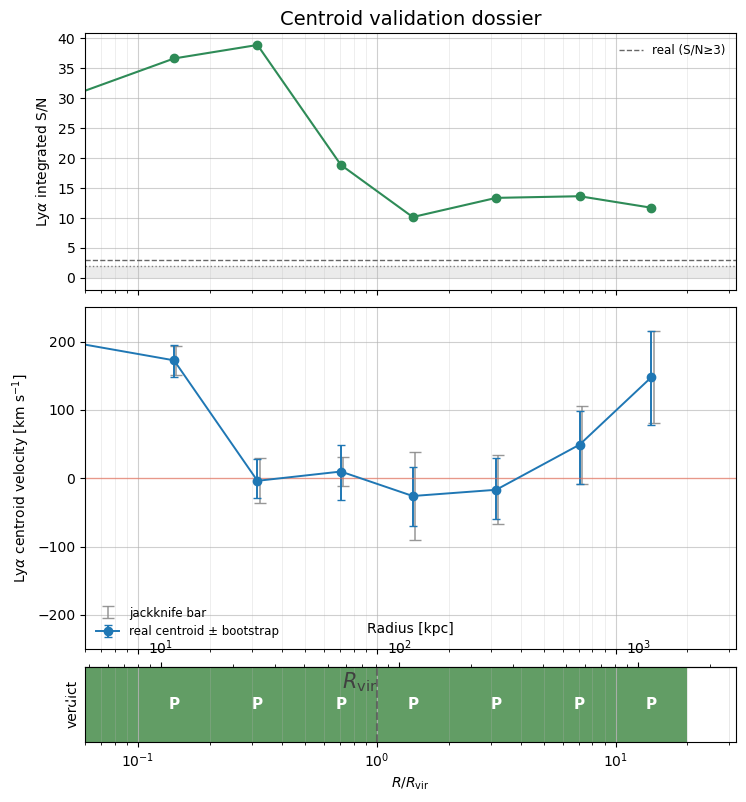


validation summary (centroid, bins in None):
     bin  verdict   gate S/N  JK/boot  bias/bar  notes
----------------------------------------------------------
   0-0.1     PASS       30.1     1.20        --  passes available checks
 0.1-0.2     PASS       36.7     0.91        --  passes available checks
 0.2-0.5     PASS       38.9     1.20        --  passes available checks
   0.5-1     PASS       18.9     0.50        --  passes available checks
     1-2     PASS       10.2     1.10        --  passes available checks
     2-5     PASS       13.4     1.07        --  passes available checks
    5-10     PASS       13.6     0.94        --  passes available checks
   10-20     PASS       11.7     1.05        --  passes available checks

  8 pass, 0 warn, 0 fail   (gate=line presence, JK/boot=error honesty, bias=injection [advisory])


NameError: name 'inj' is not defined

In [12]:
boot = measuring.run_measurement_suite(cfg, stacks)        # the real measurement
sn   = validation.signal_to_noise_spectrum(cfg, stacks)    # fast gate
ec   = validation.error_cross_check(cfg, stacks)           # fast error honesty check

validation.centroid_dossier(boot, sn=sn, error_check=ec)             # instant, no injection
#validation.centroid_dossier(boot, sn=sn, error_check=ec, injection=inj)  # if you have it

# Contributing Fiber Spectra

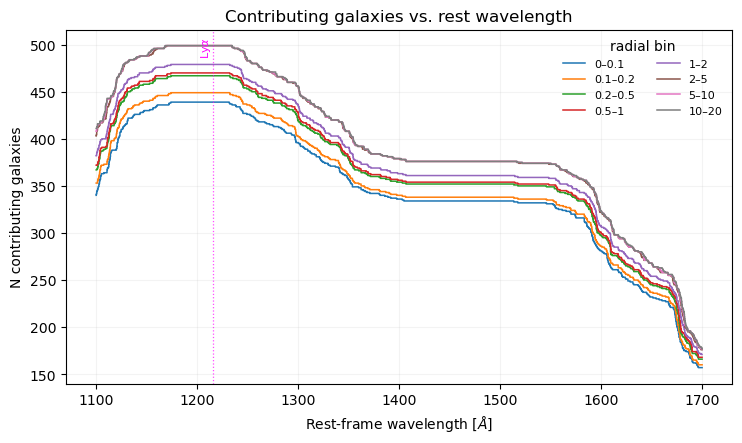

(<Figure size 860x460 with 1 Axes>,
 <Axes: title={'center': 'Contributing galaxies vs. rest wavelength'}, xlabel='Rest-frame wavelength [$\\AA$]', ylabel='N contributing galaxies'>)

In [19]:
# all radial bins overlaid on one plot (the most useful view)
plotting.plot_contributing_spectra(
    stacks,
    per_bin=True,          # one curve per radial bin
    mark_lya=True)

# Integrated Flux Spectrum (similar to SN spectrum)

windowed flux scan: 518 centers (1137–1654 Å, step 1), window ±4.0 Å, method=biweight


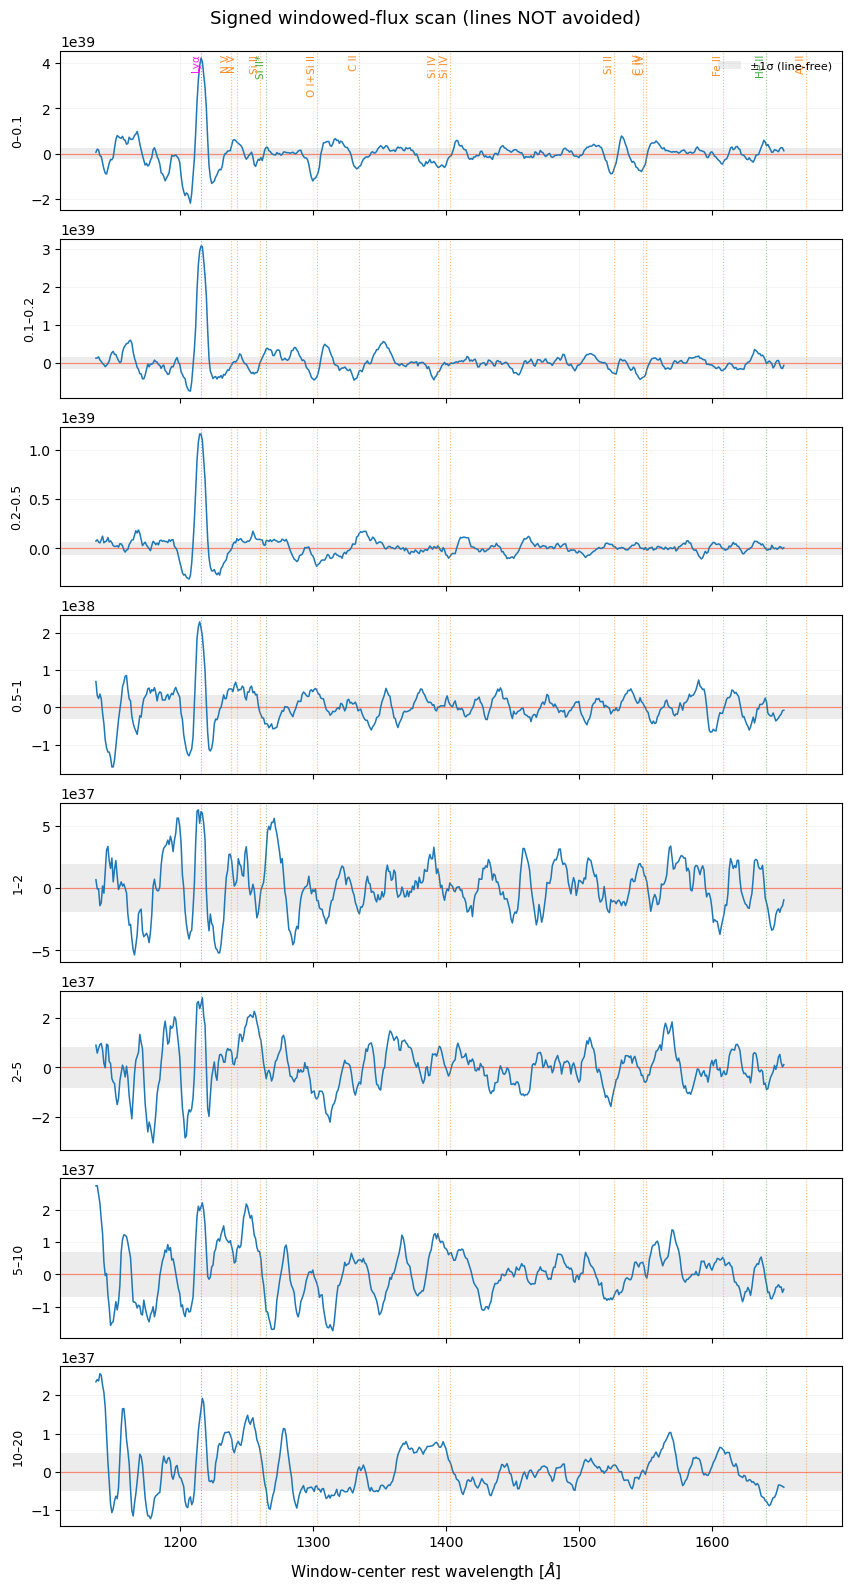

(<Figure size 840x1580 with 8 Axes>,
 array([[<Axes: ylabel='0–0.1'>],
        [<Axes: ylabel='0.1–0.2'>],
        [<Axes: ylabel='0.2–0.5'>],
        [<Axes: ylabel='0.5–1'>],
        [<Axes: ylabel='1–2'>],
        [<Axes: ylabel='2–5'>],
        [<Axes: ylabel='5–10'>],
        [<Axes: ylabel='10–20'>]], dtype=object))

In [11]:
scan = validation.windowed_flux_scan(cfg, stacks,
    step=1.0,
    half_window=4)
validation.plot_windowed_scan(scan, bins="all")

# SN Spectrum Computation

  0%|          | 0/1000 [00:00<?, ?it/s]


S/N spectrum (method=biweight). Continuum-region S/N std should be ≈1:
  0-0.1: S/N_cont std=1.10 med=+0.01 | Lyα int S/N=+27.6
  0.1-0.2: S/N_cont std=1.10 med=+0.03 | Lyα int S/N=+34.6
  0.2-0.5: S/N_cont std=0.97 med=-0.02 | Lyα int S/N=+38.1
  0.5-1: S/N_cont std=1.00 med=-0.00 | Lyα int S/N=+18.9
  1-2: S/N_cont std=1.00 med=-0.01 | Lyα int S/N=+10.2
  2-5: S/N_cont std=0.91 med=+0.01 | Lyα int S/N=+13.4
  5-10: S/N_cont std=0.83 med=+0.01 | Lyα int S/N=+13.2
  10-20: S/N_cont std=0.76 med=+0.04 | Lyα int S/N=+11.7


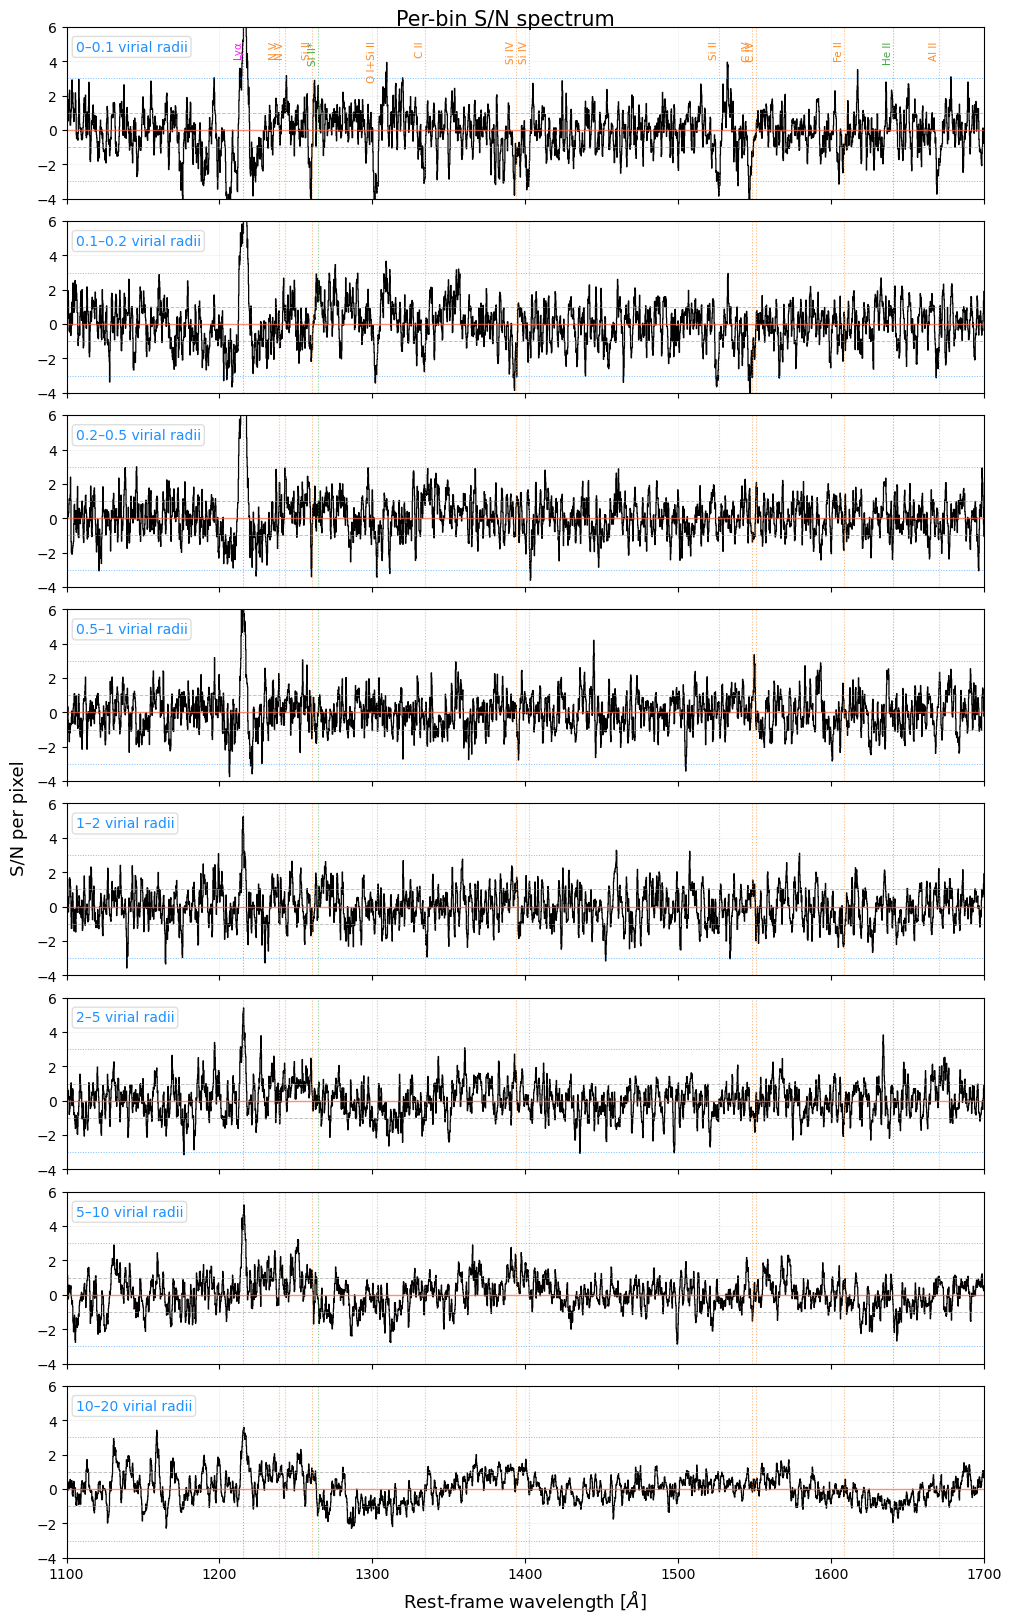

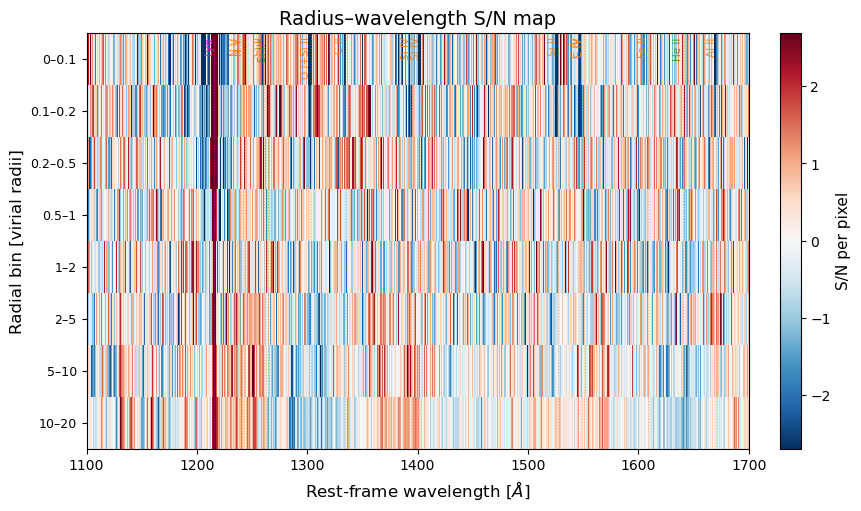

array([[         nan,  27.57225199,   3.37311835,   6.80901469,
         -2.94467598,   6.66010681,  -9.07839792,  -4.53978163,
         -8.23452887,  -4.87006548,  -8.04196528,  -9.00896916,
         -2.02208306,  -3.60122783,   4.80445633,  -7.17952853],
       [         nan,  34.63664989,  -0.40836487,   1.99986604,
         -0.93514102,   8.17564811,  -5.32906647,  -4.79355261,
         -5.92121514,  -2.03849588,  -9.13716279, -10.48173227,
         -4.30960093,  -1.82017638,   1.64473675,  -2.98887261],
       [         nan,  38.07739422,   1.5807262 ,   4.48956776,
          2.3124391 ,   2.37699668,  -6.18499077,   7.09710545,
          0.37687518,  -4.06789345,  -1.89141211,  -0.84274181,
         -0.58832994,  -0.7891914 ,  -1.12574853,  -2.68615871],
       [         nan,  18.88564326,   1.42030912,   2.01575122,
         -1.66110213,  -1.42860846,   2.23580739,  -1.96459519,
         -2.09829602,   2.16524791,   1.18474214,   2.61499521,
          1.99785171,  -1.52112459,  

In [12]:
#LOOK INTO ADJUSTING CONTINUUM AND GENERAL COMPUTATION METHODS

sn = validation.signal_to_noise_spectrum(cfg, 
     stacks,
     method=stack_method,
     nboot=n_bootstrap,
     cont_mask_hw=8.0,
     cont_order=3,
     line_hw=half_width,
     robust=True,
     seed=random_seed,
     verbose=True)

validation.plot_sn_spectrum(sn)                 # one S/N panel per bin, lines marked
validation.plot_sn_map(sn)                       # 2D radius–wavelength S/N map (the cool plot)
#sn["line_table"]["int_snr"]                      # (nrad, nline) significance of each line per bin

# --- Individual Noise Floor Tests ---

# Scattered Redshift Test

In [19]:
z_scramble = validation.redshift_scramble_null(cfg2, mega, 
     n_realizations=200,
     stack_method="biweight", 
     real_boot=boot,
     bounds=None,
     seed=random_seed,
     verbose=True)

Capping logMstar 11.37 -> 11.00, z=2.163
Capping logMstar 11.01 -> 11.00, z=2.296
Capping logMstar 11.34 -> 11.00, z=2.297
Capping logMstar 11.34 -> 11.00, z=2.297
Capping logMstar 11.04 -> 11.00, z=2.187
Capping logMstar 11.21 -> 11.00, z=2.471
Capping logMstar 11.18 -> 11.00, z=2.292
Capping logMstar 11.18 -> 11.00, z=2.114
Capping logMstar 11.28 -> 11.00, z=2.365
Capping logMstar 11.07 -> 11.00, z=2.475
Capping logMstar 11.29 -> 11.00, z=2.191
Capping logMstar 11.06 -> 11.00, z=2.562
Capping logMstar 11.11 -> 11.00, z=2.442
Capping logMstar 11.74 -> 11.00, z=2.447
Capping logMstar 11.43 -> 11.00, z=2.102
Capping logMstar 11.23 -> 11.00, z=2.465
Capping logMstar 11.19 -> 11.00, z=2.468
Capping logMstar 11.06 -> 11.00, z=2.472
Capping logMstar 11.06 -> 11.00, z=2.479
Capping logMstar 11.23 -> 11.00, z=2.471
Capping logMstar 11.63 -> 11.00, z=2.487
Capping logMstar 11.30 -> 11.00, z=2.446
Capping logMstar 11.08 -> 11.00, z=3.179


z-scramble:   0%|          | 0/200 [00:00<?, ?it/s]

Capping logMstar 11.37 -> 11.00, z=2.214
Capping logMstar 11.01 -> 11.00, z=2.303
Capping logMstar 11.34 -> 11.00, z=2.124
Capping logMstar 11.34 -> 11.00, z=2.151
Capping logMstar 11.04 -> 11.00, z=2.144
Capping logMstar 11.21 -> 11.00, z=2.151
Capping logMstar 11.18 -> 11.00, z=2.243
Capping logMstar 11.18 -> 11.00, z=2.372
Capping logMstar 11.28 -> 11.00, z=2.098
Capping logMstar 11.07 -> 11.00, z=2.434
Capping logMstar 11.29 -> 11.00, z=2.355
Capping logMstar 11.06 -> 11.00, z=3.219
Capping logMstar 11.11 -> 11.00, z=2.464
Capping logMstar 11.74 -> 11.00, z=2.146
Capping logMstar 11.43 -> 11.00, z=2.185
Capping logMstar 11.23 -> 11.00, z=2.549
Capping logMstar 11.19 -> 11.00, z=2.197
Capping logMstar 11.06 -> 11.00, z=2.131
Capping logMstar 11.06 -> 11.00, z=2.350
Capping logMstar 11.23 -> 11.00, z=2.529
Capping logMstar 11.63 -> 11.00, z=2.211
Capping logMstar 11.30 -> 11.00, z=2.127
Capping logMstar 11.08 -> 11.00, z=2.515


Capping logMstar 11.37 -> 11.00, z=2.325
Capping logMstar 11.01 -> 11.00, z=2.555
Capping logMstar 11.34 -> 11.00, z=2.438
Capping logMstar 11.34 -> 11.00, z=2.494
Capping logMstar 11.04 -> 11.00, z=2.527
Capping logMstar 11.21 -> 11.00, z=2.290
Capping logMstar 11.18 -> 11.00, z=2.163
Capping logMstar 11.18 -> 11.00, z=2.188
Capping logMstar 11.28 -> 11.00, z=2.295
Capping logMstar 11.07 -> 11.00, z=3.297
Capping logMstar 11.29 -> 11.00, z=2.163
Capping logMstar 11.06 -> 11.00, z=2.066
Capping logMstar 11.11 -> 11.00, z=3.257
Capping logMstar 11.74 -> 11.00, z=2.295
Capping logMstar 11.43 -> 11.00, z=2.260
Capping logMstar 11.23 -> 11.00, z=2.094
Capping logMstar 11.19 -> 11.00, z=3.134
Capping logMstar 11.06 -> 11.00, z=2.163
Capping logMstar 11.06 -> 11.00, z=2.364
Capping logMstar 11.23 -> 11.00, z=3.101
Capping logMstar 11.63 -> 11.00, z=2.292
Capping logMstar 11.30 -> 11.00, z=2.127
Capping logMstar 11.08 -> 11.00, z=2.213


Capping logMstar 11.37 -> 11.00, z=2.256
Capping logMstar 11.01 -> 11.00, z=2.491
Capping logMstar 11.34 -> 11.00, z=2.100
Capping logMstar 11.34 -> 11.00, z=3.058
Capping logMstar 11.04 -> 11.00, z=2.081
Capping logMstar 11.21 -> 11.00, z=2.191
Capping logMstar 11.18 -> 11.00, z=2.512
Capping logMstar 11.18 -> 11.00, z=2.349
Capping logMstar 11.28 -> 11.00, z=3.089
Capping logMstar 11.07 -> 11.00, z=3.005
Capping logMstar 11.29 -> 11.00, z=3.102
Capping logMstar 11.06 -> 11.00, z=2.289
Capping logMstar 11.11 -> 11.00, z=2.101
Capping logMstar 11.74 -> 11.00, z=2.144
Capping logMstar 11.43 -> 11.00, z=2.215
Capping logMstar 11.23 -> 11.00, z=3.218
Capping logMstar 11.19 -> 11.00, z=2.073
Capping logMstar 11.06 -> 11.00, z=3.121
Capping logMstar 11.06 -> 11.00, z=2.281
Capping logMstar 11.23 -> 11.00, z=2.186
Capping logMstar 11.63 -> 11.00, z=2.401
Capping logMstar 11.30 -> 11.00, z=2.068
Capping logMstar 11.08 -> 11.00, z=2.426


...

Capping logMstar 11.37 -> 11.00, z=3.465
Capping logMstar 11.01 -> 11.00, z=2.227
Capping logMstar 11.34 -> 11.00, z=2.325
Capping logMstar 11.34 -> 11.00, z=3.102
Capping logMstar 11.04 -> 11.00, z=2.290
Capping logMstar 11.21 -> 11.00, z=2.442
Capping logMstar 11.18 -> 11.00, z=2.163
Capping logMstar 11.18 -> 11.00, z=2.368
Capping logMstar 11.28 -> 11.00, z=2.235
Capping logMstar 11.07 -> 11.00, z=3.242
Capping logMstar 11.29 -> 11.00, z=2.471
Capping logMstar 11.06 -> 11.00, z=2.185
Capping logMstar 11.11 -> 11.00, z=2.501
Capping logMstar 11.74 -> 11.00, z=2.189
Capping logMstar 11.43 -> 11.00, z=2.266
Capping logMstar 11.23 -> 11.00, z=2.224
Capping logMstar 11.19 -> 11.00, z=2.574
Capping logMstar 11.06 -> 11.00, z=2.199
Capping logMstar 11.06 -> 11.00, z=2.438
Capping logMstar 11.23 -> 11.00, z=2.434
Capping logMstar 11.63 -> 11.00, z=2.044
Capping logMstar 11.30 -> 11.00, z=2.160
Capping logMstar 11.08 -> 11.00, z=2.186


Capping logMstar 11.37 -> 11.00, z=2.131
Capping logMstar 11.01 -> 11.00, z=3.433
Capping logMstar 11.34 -> 11.00, z=2.188
Capping logMstar 11.34 -> 11.00, z=2.478
Capping logMstar 11.04 -> 11.00, z=2.378
Capping logMstar 11.21 -> 11.00, z=2.166
Capping logMstar 11.18 -> 11.00, z=2.325
Capping logMstar 11.18 -> 11.00, z=2.440
Capping logMstar 11.28 -> 11.00, z=3.442
Capping logMstar 11.07 -> 11.00, z=2.489
Capping logMstar 11.29 -> 11.00, z=3.059
Capping logMstar 11.06 -> 11.00, z=3.460
Capping logMstar 11.11 -> 11.00, z=2.225
Capping logMstar 11.74 -> 11.00, z=2.232
Capping logMstar 11.43 -> 11.00, z=2.413
Capping logMstar 11.23 -> 11.00, z=3.187
Capping logMstar 11.19 -> 11.00, z=2.256
Capping logMstar 11.06 -> 11.00, z=2.017
Capping logMstar 11.06 -> 11.00, z=2.303
Capping logMstar 11.23 -> 11.00, z=2.469
Capping logMstar 11.63 -> 11.00, z=2.269
Capping logMstar 11.30 -> 11.00, z=2.166
Capping logMstar 11.08 -> 11.00, z=2.188


Capping logMstar 11.37 -> 11.00, z=2.395
Capping logMstar 11.01 -> 11.00, z=2.263
Capping logMstar 11.34 -> 11.00, z=2.441
Capping logMstar 11.34 -> 11.00, z=3.332
Capping logMstar 11.04 -> 11.00, z=3.162
Capping logMstar 11.21 -> 11.00, z=2.486
Capping logMstar 11.18 -> 11.00, z=2.274
Capping logMstar 11.18 -> 11.00, z=3.097
Capping logMstar 11.28 -> 11.00, z=3.207
Capping logMstar 11.07 -> 11.00, z=2.325
Capping logMstar 11.29 -> 11.00, z=3.298
Capping logMstar 11.06 -> 11.00, z=2.301
Capping logMstar 11.11 -> 11.00, z=2.184
Capping logMstar 11.74 -> 11.00, z=2.392
Capping logMstar 11.43 -> 11.00, z=2.478
Capping logMstar 11.23 -> 11.00, z=2.441
Capping logMstar 11.19 -> 11.00, z=2.189
Capping logMstar 11.06 -> 11.00, z=1.999
Capping logMstar 11.06 -> 11.00, z=2.292
Capping logMstar 11.23 -> 11.00, z=2.308
Capping logMstar 11.63 -> 11.00, z=2.473
Capping logMstar 11.30 -> 11.00, z=3.088
Capping logMstar 11.08 -> 11.00, z=2.278


Capping logMstar 11.37 -> 11.00, z=3.247
Capping logMstar 11.01 -> 11.00, z=2.301
Capping logMstar 11.34 -> 11.00, z=2.017
Capping logMstar 11.34 -> 11.00, z=3.433
Capping logMstar 11.04 -> 11.00, z=2.288
Capping logMstar 11.21 -> 11.00, z=2.312
Capping logMstar 11.18 -> 11.00, z=2.175
Capping logMstar 11.18 -> 11.00, z=2.281
Capping logMstar 11.28 -> 11.00, z=1.999
Capping logMstar 11.07 -> 11.00, z=2.468
Capping logMstar 11.29 -> 11.00, z=2.312
Capping logMstar 11.06 -> 11.00, z=2.294
Capping logMstar 11.11 -> 11.00, z=2.291
Capping logMstar 11.74 -> 11.00, z=3.480
Capping logMstar 11.43 -> 11.00, z=3.382
Capping logMstar 11.23 -> 11.00, z=2.408
Capping logMstar 11.19 -> 11.00, z=3.260
Capping logMstar 11.06 -> 11.00, z=2.017
Capping logMstar 11.06 -> 11.00, z=3.387
Capping logMstar 11.23 -> 11.00, z=2.214
Capping logMstar 11.63 -> 11.00, z=2.199
Capping logMstar 11.30 -> 11.00, z=3.058
Capping logMstar 11.08 -> 11.00, z=2.198


Capping logMstar 11.37 -> 11.00, z=2.369
Capping logMstar 11.01 -> 11.00, z=2.098
Capping logMstar 11.34 -> 11.00, z=2.079
Capping logMstar 11.34 -> 11.00, z=2.273
Capping logMstar 11.04 -> 11.00, z=2.230
Capping logMstar 11.21 -> 11.00, z=2.125
Capping logMstar 11.18 -> 11.00, z=2.312
Capping logMstar 11.18 -> 11.00, z=2.416
Capping logMstar 11.28 -> 11.00, z=3.162
Capping logMstar 11.07 -> 11.00, z=2.188
Capping logMstar 11.29 -> 11.00, z=2.163
Capping logMstar 11.06 -> 11.00, z=2.478
Capping logMstar 11.11 -> 11.00, z=2.287
Capping logMstar 11.74 -> 11.00, z=2.413
Capping logMstar 11.43 -> 11.00, z=3.121
Capping logMstar 11.23 -> 11.00, z=2.299
Capping logMstar 11.19 -> 11.00, z=2.139
Capping logMstar 11.06 -> 11.00, z=3.231
Capping logMstar 11.06 -> 11.00, z=2.146
Capping logMstar 11.23 -> 11.00, z=2.293
Capping logMstar 11.63 -> 11.00, z=3.418
Capping logMstar 11.30 -> 11.00, z=2.098
Capping logMstar 11.08 -> 11.00, z=3.391

z-scramble null (200 realizations, method=biweight, wind

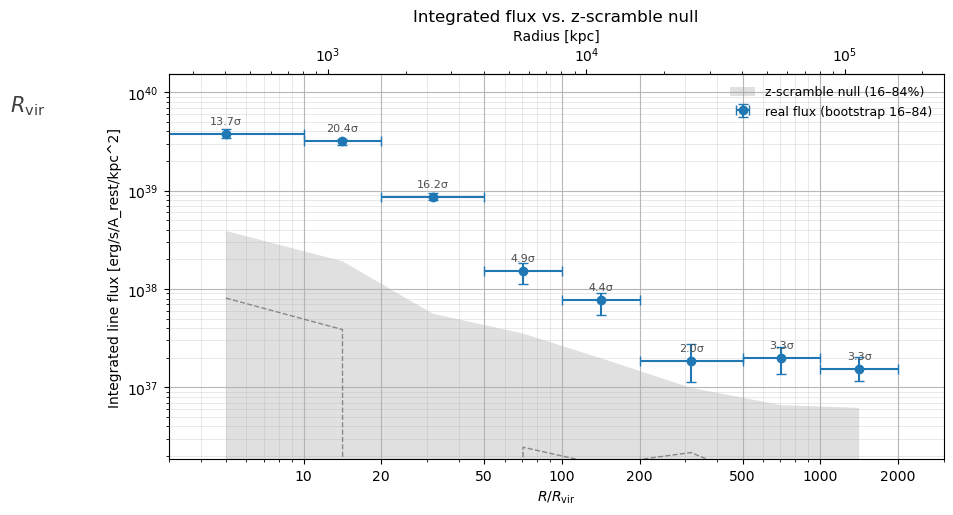

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Integrated flux vs. z-scramble null'}, xlabel='$R/R_{\\rm vir}$', ylabel='Integrated line flux [erg/s/A_rest/kpc^2]'>)

In [23]:
validation.plot_scramble_null(z_scramble,
    vr_ticks=vr_ticks,
    logy=True,
    compare_boot=True,
    figsize=(10, 5),
    ylims=None,
    xlims=xlims,
    title=None,
    save_fig=False)

# Random Wavelength Test - NOT IMPLEMENTED
Not robust enough to measure accurate error and is outclassed by others

placebo: 10 centers (method=biweight, window=±4.0 Å, abs avoided in first 0 bin(s))
  0-10: n= 10  flux null = +1.25e+38 ± 3.45e+38 [σ 3.45e+38–3.45e+38] | centroid null = -19 ± 226 km/s
  10-20: n= 10  flux null = +4.92e+37 ± 1.59e+38 [σ 1.59e+38–1.59e+38] | centroid null = -27 ± 347 km/s
  20-50: n= 10  flux null = +2.31e+36 ± 5.01e+37 [σ 5.01e+37–5.01e+37] | centroid null = +19 ± 286 km/s
  50-100: n= 10  flux null = +7.97e+36 ± 2.23e+37 [σ 2.23e+37–2.23e+37] | centroid null = -65 ± 260 km/s
  100-200: n= 10  flux null = -2.54e+36 ± 1.27e+37 [σ 1.27e+37–1.27e+37] | centroid null = +22 ± 299 km/s
  200-500: n= 10  flux null = -8.06e+36 ± 5.04e+36 [σ 5.04e+36–5.04e+36] | centroid null = +48 ± 419 km/s
  500-1000: n= 10  flux null = -1.98e+36 ± 5.7e+36 [σ 5.7e+36–5.7e+36] | centroid null = +145 ± 323 km/s
  1000-2000: n= 10  flux null = -5.27e+36 ± 4.38e+36 [σ 4.38e+36–4.38e+36] | centroid null = +139 ± 359 km/s


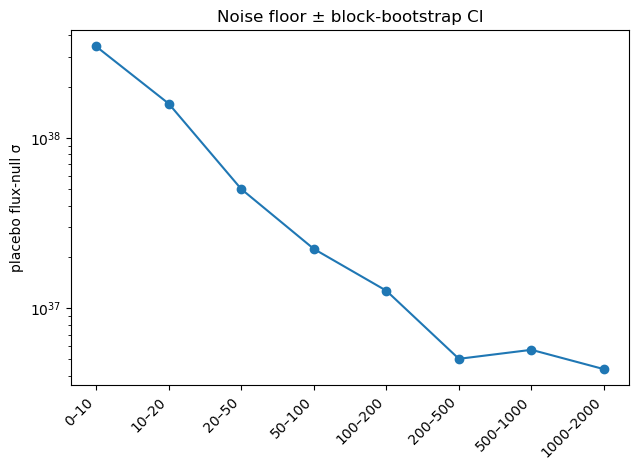

In [14]:
pb = validation.placebo_wavelengths(cfg, stacks, center_bounds=(1216, 1600),
                             abs_avoid_nbins=0, nboot_floor=1000)

# floor σ with its moving-block CI per bin
e = np.round(pb["r_edges"], 3)
x = np.arange(len(pb["flux_null_std"]))
yerr = np.vstack([pb["flux_null_std"] - pb["flux_null_std_lo"],
                  pb["flux_null_std_hi"] - pb["flux_null_std"]])
plt.errorbar(x, pb["flux_null_std"], yerr=yerr, fmt="o-", capsize=3)
plt.xticks(x, [f"{e[i]:g}–{e[i+1]:g}" for i in x], rotation=45, ha="right")
plt.ylabel("placebo flux-null σ"); plt.title("Noise floor ± block-bootstrap CI")
plt.tight_layout(); plt.yscale('log'); plt.show()

placebo: 8 line-free centers, method=biweight, window=±4.0 Å
  0-10: flux null = +4.83e+38 ± 2.77e+38 | centroid null = -223 ± 339 km/s  (ok 100%)
  10-20: flux null = +1.52e+38 ± 1.09e+38 | centroid null = -122 ± 268 km/s  (ok 100%)
  20-50: flux null = +7.06e+37 ± 1.09e+38 | centroid null = -19 ± 90 km/s  (ok 100%)
  50-100: flux null = -2.23e+37 ± 5.34e+37 | centroid null = -167 ± 352 km/s  (ok 100%)
  100-200: flux null = +1.02e+37 ± 2.58e+37 | centroid null = -26 ± 307 km/s  (ok 100%)
  200-500: flux null = +3.77e+35 ± 5.88e+36 | centroid null = -22 ± 409 km/s  (ok 100%)
  500-1000: flux null = -1.37e+36 ± 1.14e+37 | centroid null = -155 ± 385 km/s  (ok 100%)
  1000-2000: flux null = +3.59e+36 ± 1.17e+37 | centroid null = +23 ± 402 km/s  (ok 100%)


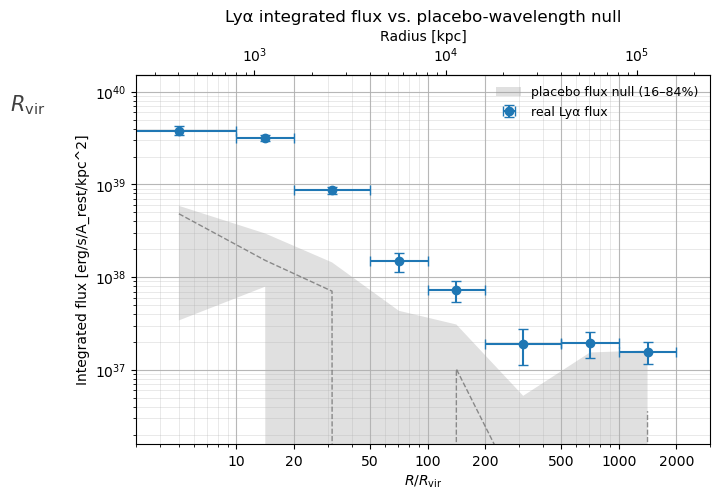

(<Figure size 740x480 with 1 Axes>,
 <Axes: title={'center': 'Lyα integrated flux vs. placebo-wavelength null'}, xlabel='$R/R_{\\rm vir}$', ylabel='Integrated flux [erg/s/A_rest/kpc^2]'>)

In [29]:
plac = validation.placebo_wavelengths(
    cfg, stacks,
    centers=None,        # None -> auto grid of line-free rest centers
    method=None,         # galaxy-combine to read; None -> "biweight"
    half_window=None,    # None -> half of cfg.line_window width
    step=4.0,            # grid spacing (Å) when auto-generating centers
    avoid=validation.DEFAULT_UV_LINES,   # lines to steer clear of
    avoid_hw=10.0,       # keep centers ≥ this far (Å) from any avoid line
    pad=2.0,             # extra footprint padding for the avoid test
    verbose=True)

# real Lya overlaid WITH its bootstrap band, log y for the faint outer bins
validation.plot_placebo(plac,
                        real_boot=boot,
                        vr_ticks=vr_ticks,
                        which="flux",
                        xlims=xlims,
                        logy=True)

# Random Position Test - NOT IMPLEMENTED
Needs extensive halo measurements in large circles

In [10]:
sky_filename = 'outputs_starpsf/galaxy_catc1488c_b8_8c91de_AEGIS_RANDOM_SKY_virial_biweight_image_bg57-63.fits'
sky_product = read_galaxy_fits(sky_filename)
sky_product = apply_finite_cut(sky_product, cfg.cut_radial_bin, cfg.min_good_wave)

cfg_sky = replace(cfg, 
    rest_wave_min=1150,
    rest_wave_max=1650)

sky_stacks = build_stacks(cfg_sky, sky_product)

randpos = validation.placebo_wavelengths(cfg_sky, sky_stacks,
    centers=None,        # None -> auto grid of line-free rest centers
    method=None,         # galaxy-combine to read; None -> "biweight"
    half_window=None,    # None -> half of cfg.line_window width
    step=5.0,            # grid spacing (Å) when auto-generating centers
    avoid=validation.DEFAULT_UV_LINES,   # lines to steer clear of
    avoid_hw=10.0,       # keep centers ≥ this far (Å) from any avoid line
    pad=2.0,             # extra footprint padding for the avoid test
    verbose=True)

Finite-spectrum cut (bin 7, > 100 px): kept 181 / 248 galaxies


Capping logMstar 11.04 -> 11.00, z=2.187
Capping logMstar 11.37 -> 11.00, z=2.163
Capping logMstar 11.18 -> 11.00, z=2.292
Capping logMstar 11.21 -> 11.00, z=2.471
Capping logMstar 11.34 -> 11.00, z=2.297
Capping logMstar 11.37 -> 11.00, z=2.163
Capping logMstar 11.28 -> 11.00, z=2.365
Capping logMstar 11.34 -> 11.00, z=2.297
Capping logMstar 11.01 -> 11.00, z=2.296
Capping logMstar 11.18 -> 11.00, z=2.114
placebo: 8 line-free centers, method=biweight, window=±4.0 Å
  0-0.1: flux null = -1.04e+38 ± 1.7e+38 | centroid null = -65 ± 241 km/s  (ok 100%)
  0.1-0.2: flux null = -2.28e+37 ± 1.39e+38 | centroid null = -82 ± 185 km/s  (ok 100%)
  0.2-0.5: flux null = -1.17e+37 ± 5.44e+37 | centroid null = -26 ± 119 km/s  (ok 100%)
  0.5-1: flux null = +3.33e+36 ± 1.08e+37 | centroid null = -34 ± 274 km/s  (ok 100%)
  1-2: flux null = -2.07e+35 ± 1.79e+37 | centroid null = -111 ± 188 km/s  (ok 100%)
  2-5: flux null = +6.42e+36 ± 9.88e+36 | centroid null = -135 ± 158 km/s  (ok 100%)
  5-10: flux

windowed flux scan: 418 centers (1187–1604 Å, step 1), window ±4.0 Å, method=biweight


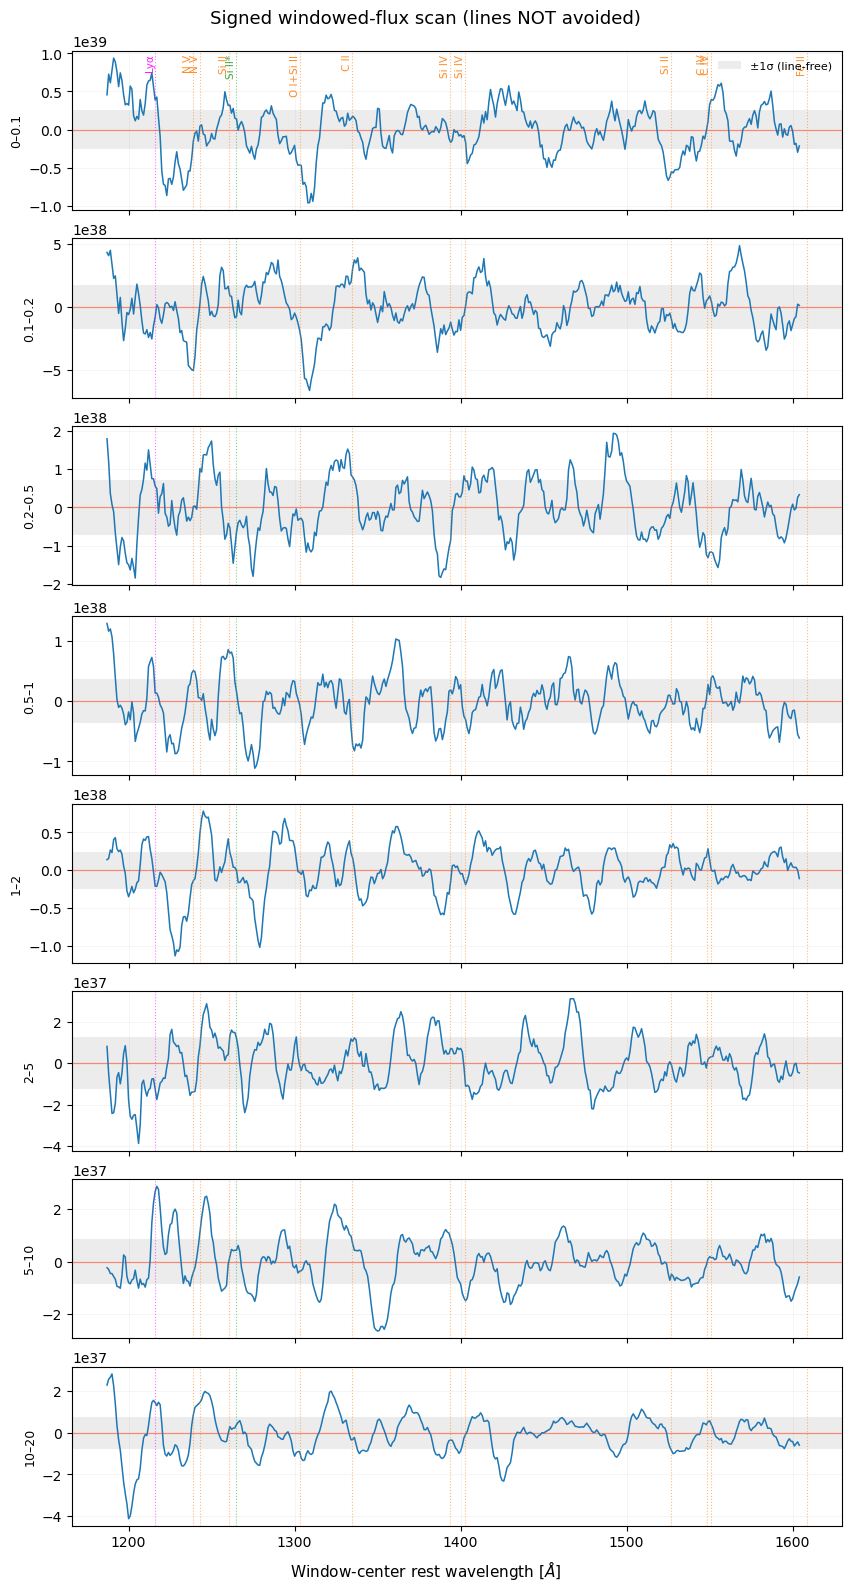

(<Figure size 840x1580 with 8 Axes>,
 array([[<Axes: ylabel='0–0.1'>],
        [<Axes: ylabel='0.1–0.2'>],
        [<Axes: ylabel='0.2–0.5'>],
        [<Axes: ylabel='0.5–1'>],
        [<Axes: ylabel='1–2'>],
        [<Axes: ylabel='2–5'>],
        [<Axes: ylabel='5–10'>],
        [<Axes: ylabel='10–20'>]], dtype=object))

In [11]:
sky_scan = validation.windowed_flux_scan(cfg_sky, sky_stacks, step=1.0)
validation.plot_windowed_scan(sky_scan, bins="all")

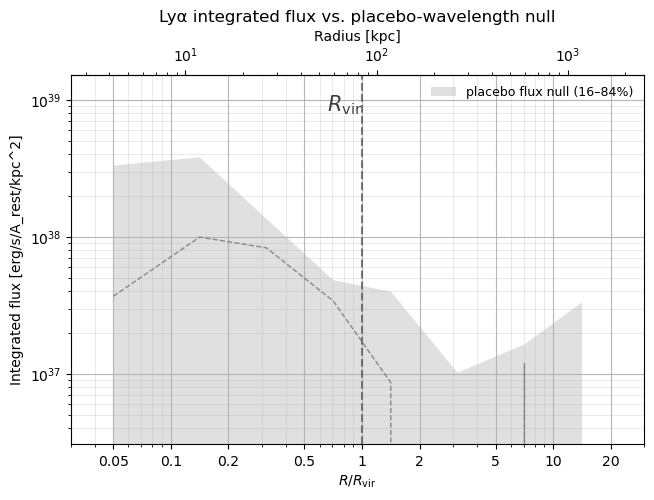

(<Figure size 740x480 with 1 Axes>,
 <Axes: title={'center': 'Lyα integrated flux vs. placebo-wavelength null'}, xlabel='$R/R_{\\rm vir}$', ylabel='Integrated flux [erg/s/A_rest/kpc^2]'>)

In [19]:
validation.plot_placebo(randpos, 
    which="flux",
    vr_ticks=(0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10, 20),
    xlims=(0.03, 30),
    logy=True)